In [13]:
import pandas as pd
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

df = pd.read_csv("../Ontrac_data.csv")
df.head()

,Invoice_Date,Client,Products,Amount,Bank_Document
0,9/2/2025,NOVAQUA,SIKACERAM 80I WHITE+GREY,21420.00,TRANSFER RECEIVED
1,9/8/2025,MY DE CONSTRUCTION,REBAR 08 TOR FE 500,11144.00,COLLECTION OF 1 BILL OF EXCHANGE
2,9/17/2025,TERRASTRUCT,CEMENT CPJ35 (21 T +19 bags),36790.00,TRANSFER RECEIVED
3,9/22/2025,STE DERRAB LISSAKAN,SIKACERAM 80I WHITE + GREY,4998.68,OFF-BRANCH CASH DEPOSIT
4,9/23/2025,STE DERRAB LISSAKAN,WOOD TALK LOUVERS 200X1200,4999.60,OFF-BRANCH CASH DEPOSIT


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean columns
df["Client"] = df["Client"].astype(str).str.strip()
df["Bank_Document"] = df["Bank_Document"].astype(str).str.strip()

# Standardize payment method names
df["Payment_Method"] = (
    df["Bank_Document"]
    .str.upper()
    .str.strip()
)

# Optional: simplify the descriptions



## 1. Which payment methods are preferred by each client?

In [30]:
client_payment_count = (
    df.groupby(["Client", "Payment_Method"])
      .size()
      .reset_index(name="Transaction_Count")
)

client_payment_count["Client_Total"] = (
    client_payment_count.groupby("Client")["Transaction_Count"]
    .transform("sum")
)

client_payment_count = (
    client_payment_count
    .sort_values(
        ["Client_Total", "Client", "Transaction_Count"],
        ascending=[False, True, False]
    )
    .drop(columns="Client_Total")
)

client_payment_count


,Client,Payment_Method,Transaction_Count
23,STE ARAFIK,OFF-BRANCH CASH DEPOSIT,27
2,AYOUB MARRAKECH,OFF-BRANCH CASH DEPOSIT,23
20,NOVAQUA,TRANSFER RECEIVED,22
27,STE DERRAB LISSAKAN,OFF-BRANCH CASH DEPOSIT,17
28,STE DERRAB LISSAKAN,TRANSFER RECEIVED,1
21,SCADACOM MAROC,TRANSFER RECEIVED,6
4,DISTRAC,OFF-BRANCH CASH DEPOSIT,5
5,ELIPROMO,TRANSFER RECEIVED,5
15,MESWANE,TRANSFER RECEIVED,5
8,ENT FAJER TAIBA,CHEQUE DEPOSITED FOR COLLECTION,2


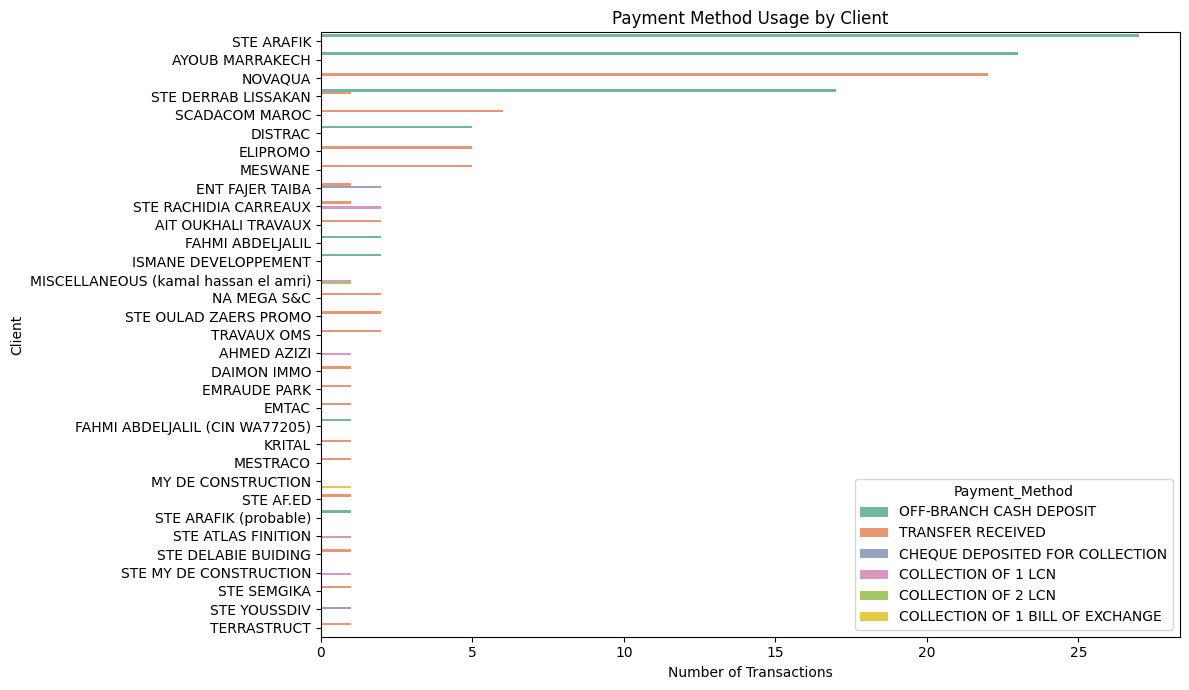

In [31]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=client_payment_count,
    x="Transaction_Count",
    y="Client",
    hue="Payment_Method",
    palette="Set2"
)

plt.title("Payment Method Usage by Client")
plt.xlabel("Number of Transactions")
plt.ylabel("Client")

plt.tight_layout()
plt.show()


## 2. Which clients primarily pay through bank transfers?

In [33]:
bank_transfer_clients = (
    df[df["Payment_Method"] == "TRANSFER RECEIVED"]
    .groupby("Client")
    .size()
    .reset_index(name="Bank_Transfer_Count")
    .sort_values("Bank_Transfer_Count", ascending=False)
)

bank_transfer_clients


,Client,Bank_Transfer_Count
10,NOVAQUA,22
11,SCADACOM MAROC,6
2,ELIPROMO,5
8,MESWANE,5
19,TRAVAUX OMS,2
15,STE OULAD ZAERS PROMO,2
0,AIT OUKHALI TRAVAUX,2
9,NA MEGA S&C,2
3,EMRAUDE PARK,1
1,DAIMON IMMO,1


## 3. Which clients use cash deposits most frequently?

In [37]:
cash_deposit_clients = (
    df[df["Payment_Method"] == "OFF-BRANCH CASH DEPOSIT"]
    .groupby("Client")
    .size()
    .reset_index(name="Cash_Deposit_Count")
    .sort_values("Cash_Deposit_Count", ascending=False)
)

print(cash_deposit_clients)


                           Client  Cash_Deposit_Count
5                      STE ARAFIK                  27
0                 AYOUB MARRAKECH                  23
7             STE DERRAB LISSAKAN                  17
1                         DISTRAC                   5
4            ISMANE DEVELOPPEMENT                   2
2                FAHMI ABDELJALIL                   2
3  FAHMI ABDELJALIL (CIN WA77205)                   1
6           STE ARAFIK (probable)                   1


## 4. Which clients primarily pay through Cheques?

In [38]:
cheque_deposit_clients = (
    df[df["Payment_Method"] == "CHEQUE DEPOSITED FOR COLLECTION"]
    .groupby("Client")
    .size()
    .reset_index(name="Cheque_Deposit_Count")
    .sort_values("Cheque_Deposit_Count", ascending=False)
)

print(cheque_deposit_clients)

            Client  Cheque_Deposit_Count
0  ENT FAJER TAIBA                     2
1     STE YOUSSDIV                     1


## 5. What is the total amount collected through each payment method by client?

In [40]:
client_payment_amount = (
    df.groupby(["Client", "Payment_Method"], as_index=False)
      .agg(
          Total_Amount=("Amount", "sum"),
          Transaction_Count=("Amount", "count"),
          Average_Amount=("Amount", "mean")
      )
      .sort_values("Total_Amount", ascending=False)
)

client_payment_amount = client_payment_amount.round(2)

client_payment_amount


,Client,Payment_Method,Total_Amount,Transaction_Count,Average_Amount
20,NOVAQUA,TRANSFER RECEIVED,839480.00,22,38158.18
21,SCADACOM MAROC,TRANSFER RECEIVED,233610.00,6,38935.00
5,ELIPROMO,TRANSFER RECEIVED,207435.00,5,41487.00
15,MESWANE,TRANSFER RECEIVED,180167.00,5,36033.40
2,AYOUB MARRAKECH,OFF-BRANCH CASH DEPOSIT,103042.79,23,4480.12
23,STE ARAFIK,OFF-BRANCH CASH DEPOSIT,101331.04,27,3753.00
31,STE RACHIDIA CARREAUX,COLLECTION OF 1 LCN,90400.00,2,45200.00
27,STE DERRAB LISSAKAN,OFF-BRANCH CASH DEPOSIT,84295.24,17,4958.54
30,STE OULAD ZAERS PROMO,TRANSFER RECEIVED,81675.00,2,40837.50
19,NA MEGA S&C,TRANSFER RECEIVED,80460.00,2,40230.00


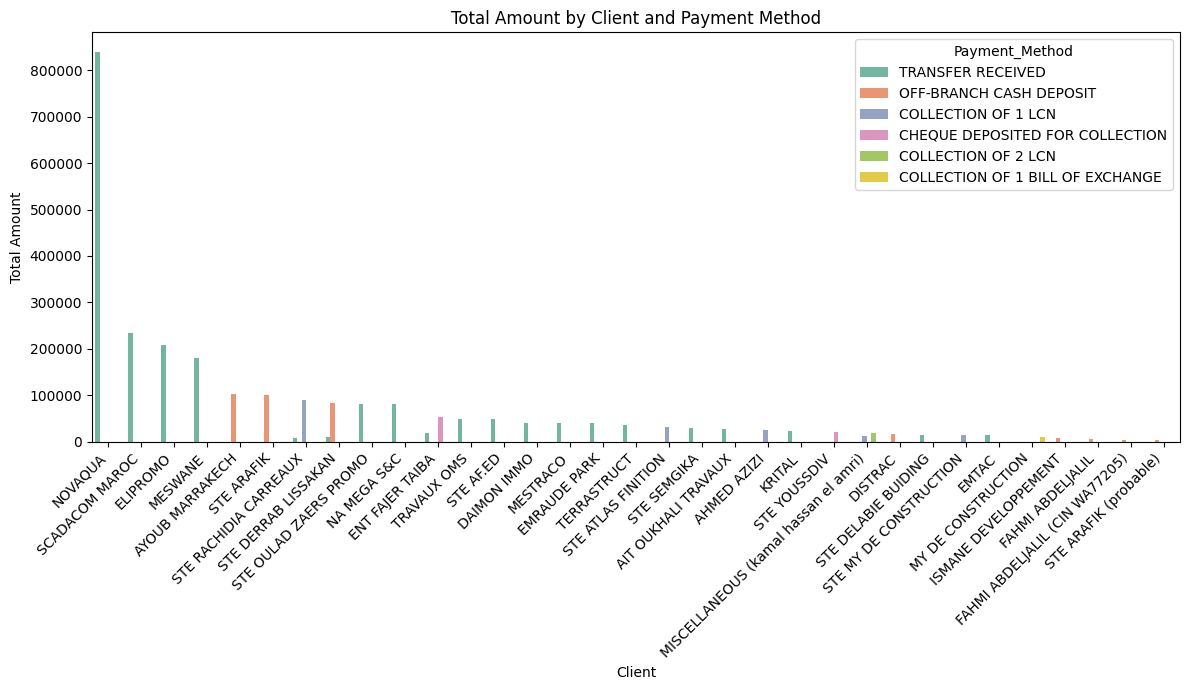

In [41]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=client_payment_amount,
    x="Client",
    y="Total_Amount",
    hue="Payment_Method",
    palette="Set2"
)

plt.title("Total Amount by Client and Payment Method")
plt.xlabel("Client")
plt.ylabel("Total Amount")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


## 6. Do different clients have different payment behaviors?

In [43]:
payment_frequency_matrix = pd.crosstab(
    df["Client"],
    df["Payment_Method"]
)

payment_frequency_matrix


Payment_Method,CHEQUE DEPOSITED FOR COLLECTION,COLLECTION OF 1 BILL OF EXCHANGE,COLLECTION OF 1 LCN,COLLECTION OF 2 LCN,OFF-BRANCH CASH DEPOSIT,TRANSFER RECEIVED
Client,,,,,,
AHMED AZIZI,0,0,1,0,0,0
AIT OUKHALI TRAVAUX,0,0,0,0,0,2
AYOUB MARRAKECH,0,0,0,0,23,0
DAIMON IMMO,0,0,0,0,0,1
DISTRAC,0,0,0,0,5,0
ELIPROMO,0,0,0,0,0,5
EMRAUDE PARK,0,0,0,0,0,1
EMTAC,0,0,0,0,0,1
ENT FAJER TAIBA,2,0,0,0,0,1


In [46]:
payment_percentage_matrix = pd.crosstab(
    df["Client"],
    df["Payment_Method"],
    normalize="index"
) * 100

payment_percentage_matrix = payment_percentage_matrix.round(2)

payment_percentage_matrix


Payment_Method,CHEQUE DEPOSITED FOR COLLECTION,COLLECTION OF 1 BILL OF EXCHANGE,COLLECTION OF 1 LCN,COLLECTION OF 2 LCN,OFF-BRANCH CASH DEPOSIT,TRANSFER RECEIVED
Client,,,,,,
AHMED AZIZI,0.00,0.0,100.00,0.0,0.00,0.00
AIT OUKHALI TRAVAUX,0.00,0.0,0.00,0.0,0.00,100.00
AYOUB MARRAKECH,0.00,0.0,0.00,0.0,100.00,0.00
DAIMON IMMO,0.00,0.0,0.00,0.0,0.00,100.00
DISTRAC,0.00,0.0,0.00,0.0,100.00,0.00
ELIPROMO,0.00,0.0,0.00,0.0,0.00,100.00
EMRAUDE PARK,0.00,0.0,0.00,0.0,0.00,100.00
EMTAC,0.00,0.0,0.00,0.0,0.00,100.00
ENT FAJER TAIBA,66.67,0.0,0.00,0.0,0.00,33.33


## 7. Identify each client's preferred payment method automatically

In [49]:
preferred_payment = (
    df.groupby(["Client", "Payment_Method"])
      .size()
      .reset_index(name="Transaction_Count")
      .sort_values(
          ["Client", "Transaction_Count"],
          ascending=[True, False]
      )
)

preferred_payment = (
    preferred_payment
    .groupby("Client")
    .head(1)
    .reset_index(drop=True)
)

preferred_payment


,Client,Payment_Method,Transaction_Count
0,AHMED AZIZI,COLLECTION OF 1 LCN,1
1,AIT OUKHALI TRAVAUX,TRANSFER RECEIVED,2
2,AYOUB MARRAKECH,OFF-BRANCH CASH DEPOSIT,23
3,DAIMON IMMO,TRANSFER RECEIVED,1
4,DISTRAC,OFF-BRANCH CASH DEPOSIT,5
5,ELIPROMO,TRANSFER RECEIVED,5
6,EMRAUDE PARK,TRANSFER RECEIVED,1
7,EMTAC,TRANSFER RECEIVED,1
8,ENT FAJER TAIBA,CHEQUE DEPOSITED FOR COLLECTION,2
9,FAHMI ABDELJALIL,OFF-BRANCH CASH DEPOSIT,2


In [51]:
client_payment_summary = (
    df.groupby(["Client", "Payment_Method"])
      .agg(
          Transaction_Count=("Amount", "count"),
          Total_Amount=("Amount", "sum"),
          Average_Amount=("Amount", "mean"),
          Minimum_Amount=("Amount", "min"),
          Maximum_Amount=("Amount", "max")
      )
      .reset_index()
)

# Total transactions for each client
client_payment_summary["Client_Total_Transactions"] = (
    client_payment_summary
    .groupby("Client")["Transaction_Count"]
    .transform("sum")
)

# Percentage of client's transactions using payment method
client_payment_summary["Payment_Method_Share_%"] = (
    client_payment_summary["Transaction_Count"]
    / client_payment_summary["Client_Total_Transactions"]
    * 100
)

client_payment_summary = (
    client_payment_summary
    .round(2)
    .sort_values(["Client", "Total_Amount"], ascending=[True, False])
)

client_payment_summary


,Client,Payment_Method,Transaction_Count,Total_Amount,Average_Amount,Minimum_Amount,Maximum_Amount,Client_Total_Transactions,Payment_Method_Share_%
0,AHMED AZIZI,COLLECTION OF 1 LCN,1,24900.00,24900.00,24900.00,24900.00,1,100.00
1,AIT OUKHALI TRAVAUX,TRANSFER RECEIVED,2,26760.00,13380.00,10600.00,16160.00,2,100.00
2,AYOUB MARRAKECH,OFF-BRANCH CASH DEPOSIT,23,103042.79,4480.12,2964.38,4998.71,23,100.00
3,DAIMON IMMO,TRANSFER RECEIVED,1,40500.00,40500.00,40500.00,40500.00,1,100.00
4,DISTRAC,OFF-BRANCH CASH DEPOSIT,5,17756.20,3551.24,2700.00,4110.40,5,100.00
5,ELIPROMO,TRANSFER RECEIVED,5,207435.00,41487.00,40230.00,42080.00,5,100.00
6,EMRAUDE PARK,TRANSFER RECEIVED,1,40000.00,40000.00,40000.00,40000.00,1,100.00
7,EMTAC,TRANSFER RECEIVED,1,14239.00,14239.00,14239.00,14239.00,1,100.00
8,ENT FAJER TAIBA,CHEQUE DEPOSITED FOR COLLECTION,2,54185.00,27092.50,22560.00,31625.00,3,66.67
9,ENT FAJER TAIBA,TRANSFER RECEIVED,1,18330.00,18330.00,18330.00,18330.00,3,33.33


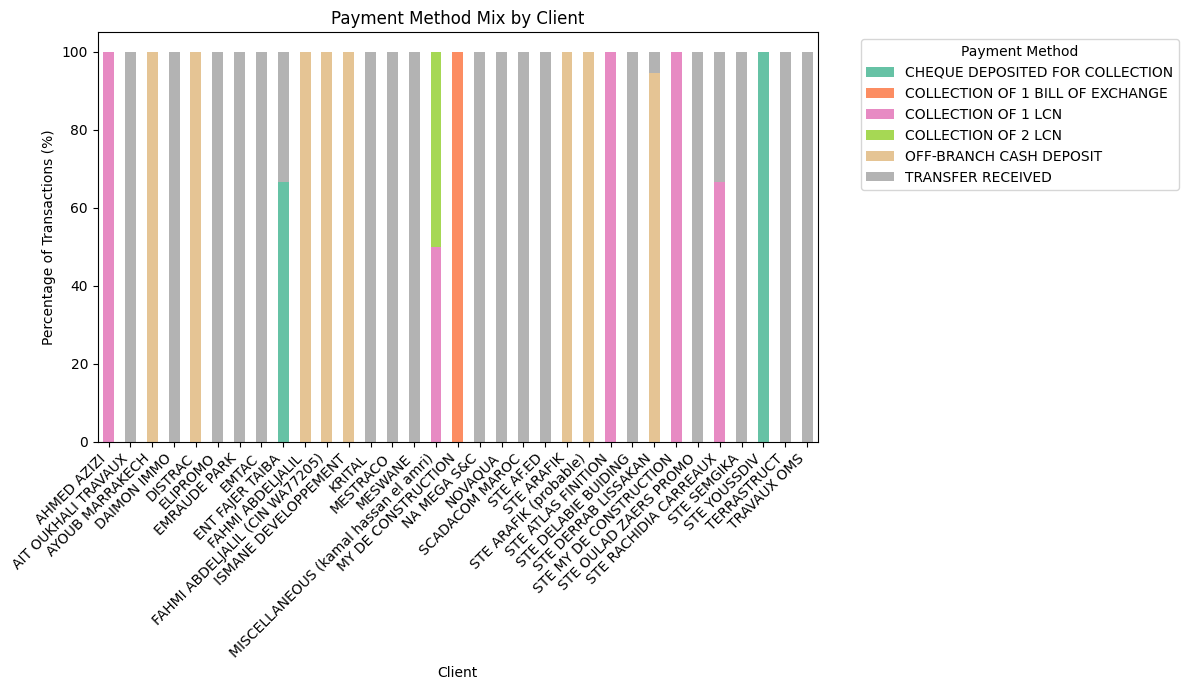

In [52]:
payment_mix = pd.crosstab(
    df["Client"],
    df["Payment_Method"],
    normalize="index"
) * 100

payment_mix.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    colormap="Set2"
)

plt.title("Payment Method Mix by Client")
plt.xlabel("Client")
plt.ylabel("Percentage of Transactions (%)")
plt.legend(
    title="Payment Method",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
